In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv("Unemployment in India.csv")

In [ ]:
#Analysis of data
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [87]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [90]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [91]:
display(df.describe(include='all'))

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,740,740,740,740.000000,7.400000e+02,740.000000,740
unique,28,14,2,NaN,NaN,NaN,2
top,Andhra Pradesh,31-10-2019,Monthly,NaN,NaN,NaN,Urban
freq,28,55,381,NaN,NaN,NaN,381
mean,NaN,NaN,NaN,11.787946,7.204460e+06,42.630122,NaN
std,NaN,NaN,NaN,10.721298,8.087988e+06,8.111094,NaN
min,NaN,NaN,NaN,0.000000,4.942000e+04,13.330000,NaN
25%,NaN,NaN,NaN,4.657500,1.190404e+06,38.062500,NaN
50%,NaN,NaN,NaN,8.350000,4.744178e+06,41.160000,NaN
75%,NaN,NaN,NaN,15.887500,1.127549e+07,45.505000,NaN


In [ ]:
#Data cleaning
df = df.dropna().reset_index(drop=True)

In [93]:
df.columns = df.columns.str.strip()

In [94]:
df['Date']= pd.to_datetime(df['Date'],errors = 'coerce')

C:\Users\jaydu\AppData\Local\Temp\ipykernel_888\748665889.py:1: UserWarning:

Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [95]:
df['Date']

0     2019-05-31
1     2019-06-30
2     2019-07-31
3     2019-08-31
4     2019-09-30
         ...    
735   2020-02-29
736   2020-03-31
737   2020-04-30
738   2020-05-31
739   2020-06-30
Name: Date, Length: 740, dtype: datetime64[ns]

In [96]:
df.drop('Frequency',axis=1,inplace = True)

In [97]:
df.duplicated().sum()

0

In [98]:
df['Area'].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

In [99]:
df.groupby('Area')['Estimated Employed'].sum()

Area
Rural    3.659234e+09
Urban    1.672066e+09
Name: Estimated Employed, dtype: float64

In [100]:
df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64

In [101]:
df['Area'].unique()

array(['Rural', 'Urban'], dtype=object)

In [102]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [103]:
df['Region'].value_counts

<bound method IndexOpsMixin.value_counts of 0      Andhra Pradesh
1      Andhra Pradesh
2      Andhra Pradesh
3      Andhra Pradesh
4      Andhra Pradesh
            ...      
735       West Bengal
736       West Bengal
737       West Bengal
738       West Bengal
739       West Bengal
Name: Region, Length: 740, dtype: object>

In [ ]:
#Exploration and visualization of trend
import  plotly.express as px

In [105]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize']=(12,6)

c:\Users\jaydu\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



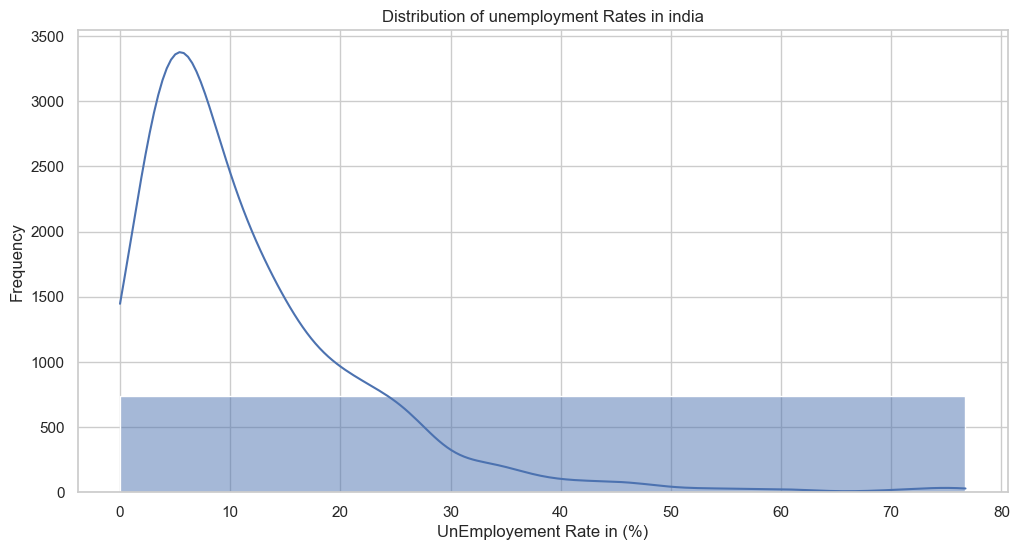

In [106]:
plt.figure()
sns.histplot(df['Estimated Unemployment Rate (%)'],bins=True,kde=True)
plt.title("Distribution of unemployment Rates in india")
plt.xlabel("UnEmployement Rate in (%)")
plt.ylabel("Frequency")
plt.show()


c:\Users\jaydu\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\jaydu\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



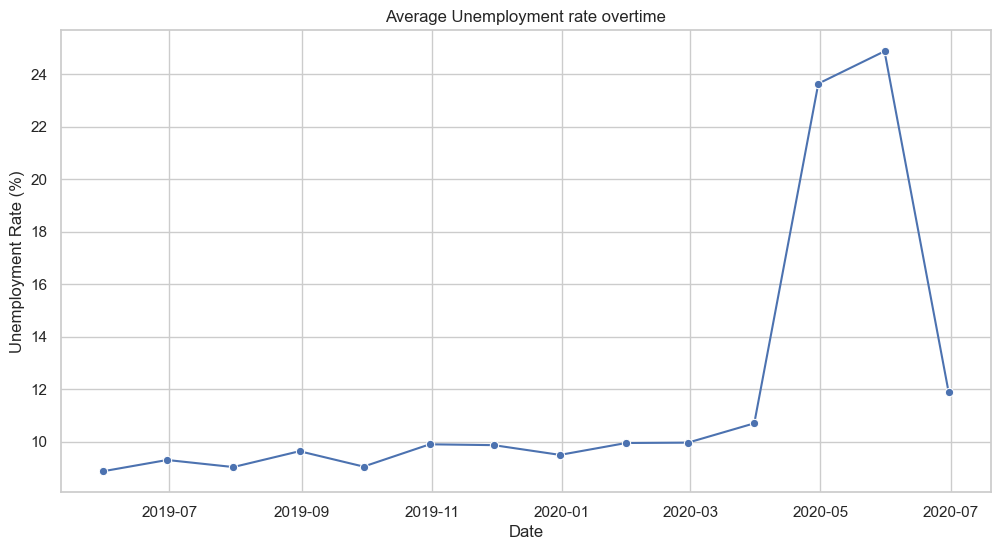

In [107]:
trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure()
sns.lineplot(data = trend ,x = 'Date',y = 'Estimated Unemployment Rate (%)',marker='o')
plt.title("Average Unemployment rate overtime")
plt.xlabel('Date')
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [122]:
#We can see that unemployment rises in 2020 due to covid

In [108]:
fig = px.line(df,x='Date',y='Estimated Unemployment Rate (%)',color='Region',
              title='Unemployment Rate Over time by Region')

fig.show()


c:\Users\jaydu\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



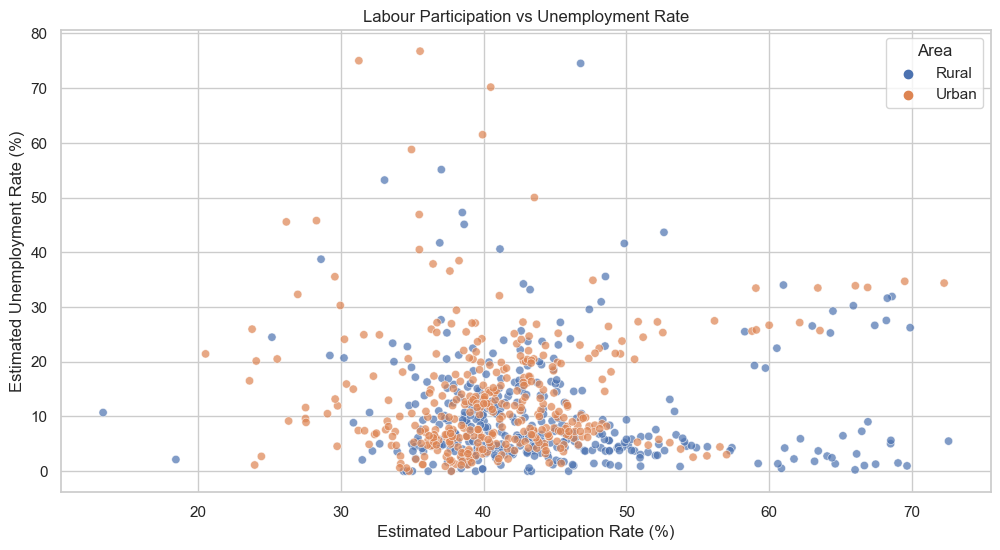

In [109]:
plt.figure()

sns.scatterplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    hue='Area',
    alpha=0.7
)
plt.title('Labour Participation vs Unemployment Rate')

plt.show()

In [ ]:
#Impact of covid-19 on unemployment rates
import numpy as np

In [111]:
covid_start = pd.Timestamp("2020-03-01")

In [113]:
print(type(covid_start))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [114]:
pre_covid = df[df['Date'] < covid_start]
during_covid = df[df['Date'] >= covid_start]

print("Pre-Covid Samples:",len(pre_covid))
print("During Covid Samples",len(during_covid))

Pre-Covid Samples: 536
During Covid Samples 204


In [116]:
pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
during_mean = during_covid['Estimated Unemployment Rate (%)'].mean()

print(f"Average Unemployment Rate Before COVID: {pre_mean:.2f}%")
print(f"Average Unemployment Rate during COVID:{during_mean:.2f}%")

Average Unemployment Rate Before COVID: 9.51%
Average Unemployment Rate during COVID:17.77%


c:\Users\jaydu\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



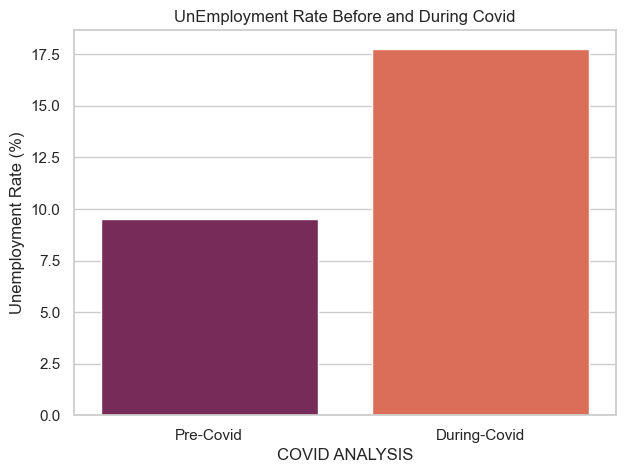

In [117]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=['Pre-Covid','During-Covid'],y=[pre_mean,during_mean],palette='rocket')
plt.title("UnEmployment Rate Before and During Covid")
plt.xlabel("COVID ANALYSIS")
plt.ylabel("Unemployment Rate (%)")
plt.show()

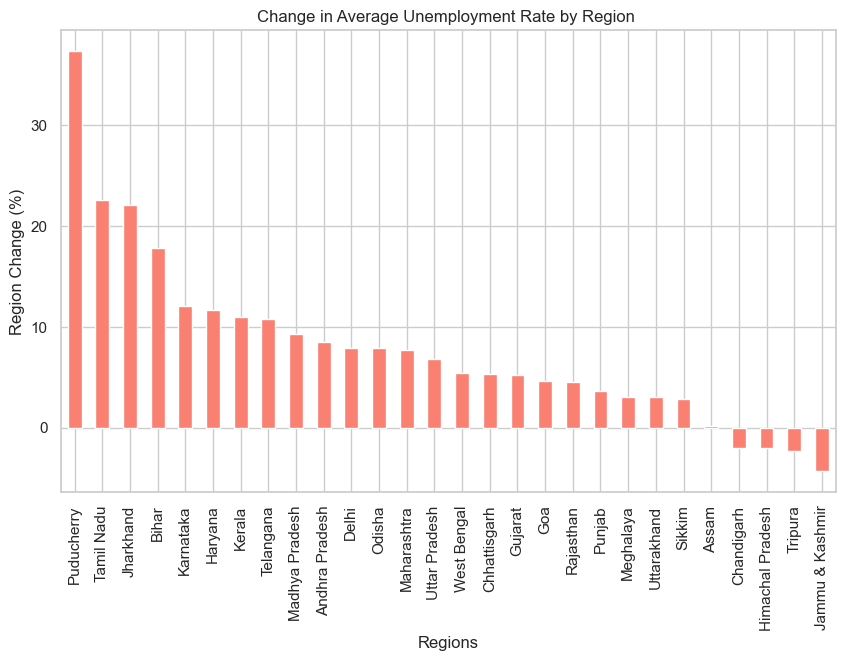

In [119]:
region_change = (
    during_covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
    -pre_covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
).sort_values(ascending=False).dropna()

plt.figure(figsize=(10,6))
region_change.plot(kind='bar',color='salmon')
plt.title('Change in Average Unemployment Rate by Region ')
plt.xlabel("Regions")
plt.ylabel("Region Change (%)")
plt.xticks(rotation=90)
plt.show()

In [120]:
df.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural


In [121]:
df.to_csv("Cleaned_Data.csv",index=False)